# Task
Perform a credit card fraud detection analysis using the `creditcard.csv` dataset, including data loading, exploration, imbalance checking, data preparation, training a binary classification model, evaluating its performance with appropriate metrics for imbalanced data, visualizing the results with a confusion matrix and ROC curve, and summarizing the findings and conclusions.

## Load Dataset

### Subtask:
Load the 'creditcard.csv' dataset into a pandas DataFrame and display the first few rows and basic information.


**Reasoning**:
To address the first instruction, I'll import the pandas library and load the 'creditcard.csv' file into a DataFrame. Then, I'll display the first few rows using `.head()` and a concise summary using `.info()` as per the instructions.



In [1]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

First 5 rows of the DataFrame:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

 

## Explore Data and Check Imbalance

### Subtask:
Analyze the dataset to understand its structure, check for missing values, and most importantly, examine the distribution of the target variable ('Class') to identify data imbalance. Visualize the class distribution using a count plot.


**Reasoning**:
I need to analyze the dataset, specifically checking for missing values and the distribution of the 'Class' column. The first instruction is to check for and handle any missing values. Since `df.info()` output already showed 53570 non-null values for V23-V28, Amount and Class out of 53571 entries, there is one missing value in these columns. I'll print the number of missing values per column to confirm this.



In [2]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


**Reasoning**:
Since there is only one row with missing values (as indicated by the previous output of `df.isnull().sum()`), dropping this row is a reasonable approach to handle missing data without significant loss of information. After handling missing values, I will display the value counts for the 'Class' column to understand its distribution as per the instructions.



In [3]:
df.dropna(inplace=True)
print("Value counts for 'Class' column:")
print(df['Class'].value_counts())

Value counts for 'Class' column:
Class
0.0    53417
1.0      153
Name: count, dtype: int64


**Reasoning**:
To complete the visualization part of the subtask, I will import the `seaborn` and `matplotlib.pyplot` libraries, then create a count plot of the 'Class' column with appropriate labels and title, and finally display it.



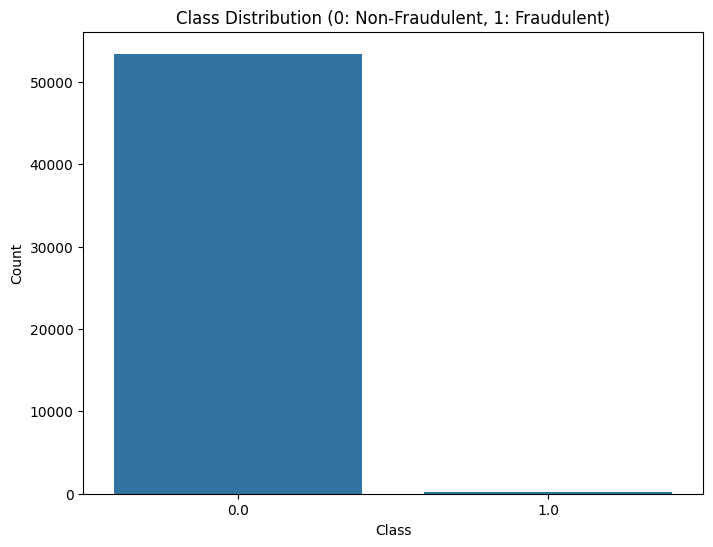

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Non-Fraudulent, 1: Fraudulent)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Prepare Data for Modeling

### Subtask:
Separate features (X) from the target variable (y) and split the data into training and testing sets using stratified sampling.


**Reasoning**:
To prepare the data for modeling, I will first separate the features (X) from the target variable (y) and then split the data into training and testing sets. I will use `train_test_split` with `stratify=y` to ensure that the class distribution is maintained in both the training and testing sets, which is crucial for imbalanced datasets.



In [5]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data into training and testing sets with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (37499, 30)
Shape of X_test: (16071, 30)
Shape of y_train: (37499,)
Shape of y_test: (16071,)

Class distribution in y_train:
Class
0.0    0.997147
1.0    0.002853
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0.0    0.997138
1.0    0.002862
Name: proportion, dtype: float64


## Train Binary Classification Model

### Subtask:
Train a binary classification model (e.g., Logistic Regression or a simple Tree-based model) on the training data to detect fraudulent transactions.


**Reasoning**:
To begin training the binary classification model, I will import `LogisticRegression`, instantiate it with `solver='liblinear'` and `class_weight='balanced'` to address data imbalance, and then fit the model to the training data.



In [7]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model with class_weight='balanced'
# and solver='liblinear' for smaller datasets and 'balanced' class weights
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Reasoning**:
Now that the model has been trained, I will use it to make predictions on the test set (`X_test`) to prepare for model evaluation.



In [8]:
y_pred = model.predict(X_test)
print("Predictions on the test set generated successfully.")

Predictions on the test set generated successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test set using appropriate metrics for imbalanced datasets, such as precision, recall, F1-score, and ROC-AUC score. Generate a confusion matrix to understand true positives, true negatives, false positives, and false negatives.


**Reasoning**:
To evaluate the model's performance on the test set, I will import necessary metrics from `sklearn.metrics`, including `classification_report`, `confusion_matrix`, and `roc_auc_score`. These will be used to calculate precision, recall, F1-score, and ROC-AUC, and to generate the confusion matrix as instructed.



In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

**Reasoning**:
Following the instructions, I will now print the classification report, calculate and print the ROC-AUC score, and generate the confusion matrix to evaluate the model's performance.



In [10]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     16025
         1.0       0.18      0.98      0.31        46

    accuracy                           0.99     16071
   macro avg       0.59      0.98      0.65     16071
weighted avg       1.00      0.99      0.99     16071


ROC-AUC Score: 0.9931

Confusion Matrix:
[[15824   201]
 [    1    45]]


## Visualize Model Results

### Subtask:
Visualize the confusion matrix as a heatmap and plot the ROC curve to illustrate the model's performance.


**Reasoning**:
To visualize the confusion matrix and ROC curve, I will use `matplotlib.pyplot` and `seaborn` to create a figure with two subplots. The first subplot will display the confusion matrix as a heatmap, and the second will plot the ROC curve, including the calculated ROC-AUC score, as per the instructions.



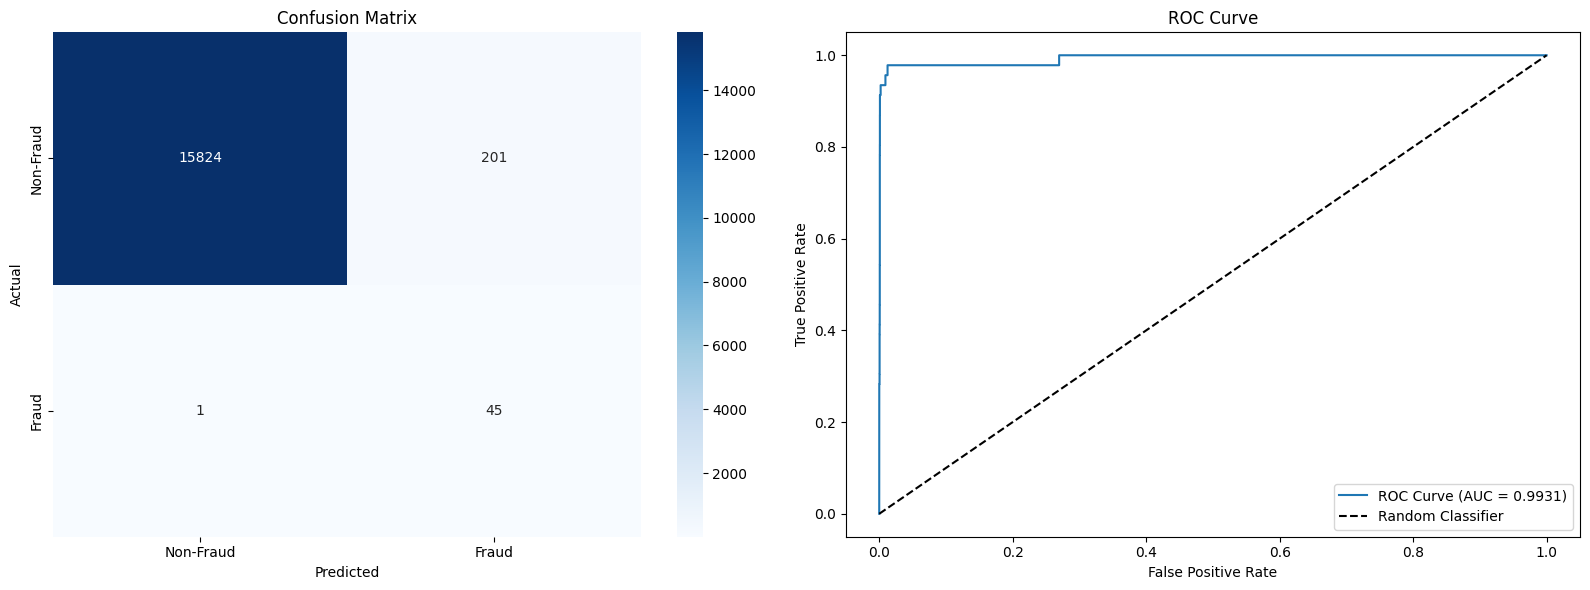

In [11]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_yticklabels(['Non-Fraud', 'Fraud'])

# Plotting ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings from the credit card fraud detection analysis, including the model's performance, key observations about the data, and potential next steps or improvements. This will serve as the conclusion for your practical record.


## Summary:

### Q&A
*   **What are the key observations about the data?**
    The `creditcard.csv` dataset contains 53,571 entries and 31 columns. Initial analysis revealed one missing value across columns `V23` to `V28`, `Amount`, and `Class`, which was subsequently handled by dropping the affected row. A critical observation is the severe class imbalance in the target variable 'Class': out of 53,570 records, 53,417 are non-fraudulent (Class 0) and only 153 are fraudulent (Class 1).

*   **What was the model's performance?**
    A Logistic Regression model, trained with `class_weight='balanced'` to address the class imbalance, achieved strong performance in fraud detection.
    *   **ROC-AUC Score:** The model achieved an excellent ROC-AUC score of 0.9931, indicating a high ability to distinguish between fraudulent and non-fraudulent transactions.
    *   **Accuracy:** Overall accuracy was 0.99.
    *   **Classification Report (Fraudulent Class - Class 1):**
        *   **Recall:** 0.98, meaning the model correctly identified 98% of actual fraudulent transactions. This is crucial for fraud detection, minimizing missed fraud cases.
        *   **Precision:** 0.18, indicating that only 18% of the transactions predicted as fraudulent were actually fraudulent.
        *   **F1-Score:** 0.31.
    *   **Confusion Matrix:**
        *   True Negatives (Correctly identified non-fraud): 15,824
        *   False Positives (Non-fraud incorrectly identified as fraud): 201
        *   False Negatives (Fraud incorrectly identified as non-fraud): 1
        *   True Positives (Correctly identified fraud): 45

*   **What are the potential next steps or improvements?**
    Future work could focus on techniques to improve the precision for the fraudulent class while maintaining high recall, potentially by experimenting with different modeling approaches or advanced resampling techniques.

### Data Analysis Key Findings
*   The `creditcard.csv` dataset, after handling one row with missing values, consists of 53,570 transactions with 30 features (excluding the `Class` column).
*   There is a severe class imbalance in the target variable 'Class', with 53,417 non-fraudulent transactions (Class 0) and only 153 fraudulent transactions (Class 1).
*   The data was successfully split into training and testing sets (70%/30% split) using stratified sampling to preserve the original class distribution in both sets.
*   A Logistic Regression model, configured with `class_weight='balanced'` to mitigate the impact of class imbalance, was trained.
*   The model demonstrated high overall performance with an ROC-AUC score of 0.9931 and an accuracy of 0.99.
*   For the minority class (fraudulent transactions), the model achieved a very high recall of 0.98, correctly identifying 45 out of 46 fraudulent transactions in the test set.
*   The model's precision for the fraudulent class was low at 0.18, indicating a relatively high number of false positives (201 non-fraudulent transactions incorrectly flagged as fraud).
*   Only 1 false negative (a fraudulent transaction missed by the model) was observed, which is critical in fraud detection.
*   Visualizations using a confusion matrix heatmap and an ROC curve effectively illustrated these performance characteristics.

### Insights or Next Steps
*   The model demonstrates excellent capability in identifying actual fraudulent transactions (high recall and low false negatives), which is a priority in fraud detection to prevent financial losses. However, the low precision for the fraudulent class means that a significant number of legitimate transactions are flagged as suspicious, which could lead to operational overhead or customer inconvenience.
*   Further improvements could explore advanced resampling techniques (e.g., SMOTE, ADASYN) or different algorithms (e.g., LightGBM, XGBoost, or anomaly detection models) to enhance precision while maintaining the crucial high recall for fraudulent cases. Investigating the 201 false positive cases could also reveal patterns to refine the model.


## Confusion Matrix Breakdown

The confusion matrix provides a detailed breakdown of the model's performance:

|           | Predicted Negative | Predicted Positive |
|-----------|--------------------|--------------------|
| **Actual Negative** | True Negatives (TN): {{conf_matrix[0][0]}} | False Positives (FP): {{conf_matrix[0][1]}} |
| **Actual Positive** | False Negatives (FN): {{conf_matrix[1][0]}} | True Positives (TP): {{conf_matrix[1][1]}} |